# Lex Triage Agent — Executive Dashboard

> **M7 deliverable** — Data-flow visualisation, telemetry deep-dive, KPIs, and CEO-level business summary.  
> Prerequisites: M5 + M6 complete; `runtime/benchmarks/latest.json` present.

Run order: **Kernel → Restart and Run All**

| Section | Content |
|---------|--------|
| §1 | Agent graph topology (nodes + edges) |
| §2 | KPI scorecard |
| §3 | Confusion matrix |
| §4 | Per-node cost breakdown |
| §5 | Latency profile (P50 / P90 / P95) |
| §6 | HITL queue analytics |
| §7 | CEO one-page summary |

In [1]:
# ── Install / verify dependencies ──────────────────────────────────────────
%pip install -q plotly pandas numpy scikit-learn kaleido "nbformat>=4.2.0"

/Users/wojciechkrukar/code/lex-triage-agent/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from sklearn.metrics import confusion_matrix, classification_report

# ── Demo flags ──────────────────────────────────────────────────────────────
# ┌─ DEMO SIMPLIFICATION ─────────────────────────────────────────────────────┐
# │ HITL_AUTO_APPROVE=true bypasses human-in-the-loop review entirely.        │
# │ Every email is passed through exactly as the agents classified it.         │
# │ ⚠️  DO NOT use in production — attorneys must review every PI lead.        │
# └───────────────────────────────────────────────────────────────────────────┘
os.environ["HITL_AUTO_APPROVE"] = "true"  # ← DEMO ONLY — remove in production
os.environ.setdefault("LLM_TIER", "tier1")
# os.environ["LLM_TIER"] = "tier1"
os.environ.setdefault("LANGSMITH_TRACING", "false")

# ── Paths ───────────────────────────────────────────────────────────────────
#  Walk up from cwd until we find the repo root (has both "apps/" and "runtime/")
REPO_ROOT = Path.cwd()
for _ in range(4):
    if (REPO_ROOT / "apps").exists() and (REPO_ROOT / "runtime").exists():
        break
    REPO_ROOT = REPO_ROOT.parent

BENCHMARKS    = REPO_ROOT / "runtime" / "benchmarks"
LATEST_JSON   = BENCHMARKS / "latest.json"
BASELINE_JSON = BENCHMARKS / "baseline.json"

pio.templates.default = "plotly_white"

print(f"Repo root : {REPO_ROOT}")
print(f"Benchmarks: {BENCHMARKS}")
print(f"latest.json exists: {LATEST_JSON.exists()}")
print()
print("⚠️  DEMO MODE: HITL_AUTO_APPROVE=true  — human review is bypassed.")
print("   All stats reflect the agents' own classifications, not attorney-reviewed decisions.")

Repo root : /Users/wojciechkrukar/code/lex-triage-agent
Benchmarks: /Users/wojciechkrukar/code/lex-triage-agent/runtime/benchmarks
latest.json exists: True

⚠️  DEMO MODE: HITL_AUTO_APPROVE=true  — human review is bypassed.
   All stats reflect the agents' own classifications, not attorney-reviewed decisions.


In [3]:
# ── Load benchmark data (falls back to synthetic demo data if file missing) ─

def _synthetic_demo() -> dict:
    """Generate a minimal synthetic report for notebook preview when no real eval exists."""
    import random, uuid
    random.seed(42)
    classes   = ["pi_lead"] * 30 + ["spam"] * 25 + ["invoice"] * 20 + ["general_legal"] * 15 + ["other"] * 10
    sinks_map = {"pi_lead":"NewLead","spam":"Refused-Spam","invoice":"Refused-Invoice",
                 "general_legal":"GeneralLegal","other":"Refused-Other"}
    records   = []
    for i, gt in enumerate(classes):
        correct = random.random() > 0.12   # ~88% accuracy demo
        pred    = sinks_map[gt] if correct else random.choice(list(sinks_map.values()))
        records.append({
            "email_id":       f"demo-{i:04d}",
            "gt_class":       gt,
            "expected_sink":  sinks_map[gt],
            "predicted_sink": pred,
            "correct":        pred == sinks_map[gt],
            "latency_ms":     int(random.gauss(4200, 800)),
            "cost_usd":       round(random.uniform(0.003, 0.015), 6),
            "error":          None,
        })
    kpis = {
        "lead_precision": 0.91, "lead_recall": 0.87, "spam_fpr": 0.015,
        "accuracy": 0.88, "mean_latency_ms": 4200, "p90_latency_ms": 5800,
        "p95_latency_ms": 7100, "total_cost_usd": sum(r["cost_usd"] for r in records),
        "n_records": len(records), "n_errors": 0,
        "tp": 26, "fp": 3, "fn": 4,
    }
    return {"run_id": "DEMO", "commit": "demo", "llm_tier": "tier1",
            "kpis": kpis, "per_record": records}


import datetime as _dt

if LATEST_JSON.exists():
    report    = json.loads(LATEST_JSON.read_text())
    _mtime    = _dt.datetime.fromtimestamp(LATEST_JSON.stat().st_mtime)
    _source   = "interactive" if str(report.get("run_id", "")).endswith("-interactive") else "CLI eval"
    print(f"Loaded real eval run:  {report['run_id']}")
    print(f"Source : {_source}    |    Records : {report['kpis']['n_records']}    |    Tier : {report.get('llm_tier', '?')}")
    print(f"File last modified : {_mtime.strftime('%Y-%m-%d %H:%M:%S')}")
    print()
    print("💡  If you just ran the interactive pipeline, re-run this cell to pick up the new results.")
else:
    report = _synthetic_demo()
    print("⚠️  No runtime/benchmarks/latest.json found — using SYNTHETIC DEMO DATA.")
    print("   Run the interactive notebook pipeline  OR  `legal-triage eval --dataset ...`")
    print("   to populate real data, then re-run this cell.")

kpis       = report["kpis"]
per_record = report["per_record"]
df         = pd.DataFrame(per_record)
df.head(3)

Loaded real eval run:  20260503T062213Z-interactive
Source : interactive    |    Records : 50    |    Tier : tier1
File last modified : 2026-05-03 01:22:13

💡  If you just ran the interactive pipeline, re-run this cell to pick up the new results.


,email_id,gt_class,expected_sink,predicted_sink,correct,latency_ms,cost_usd,error,hitl_required,human_decision
0,f143262f-dc5c-4eed-8da0-365bf89897b9,pi_lead,NewLead,NaN,False,0,0.000000,Invalid input type <class 'langchain_core.mess...,False,NaN
1,b83cfe0b-e037-45ed-b8db-0672f42d47cc,invoice,Refused-Invoice,Refused-Invoice,True,13128,0.043394,NaN,False,NaN
2,e9a1fa6f-81f7-4d1c-adbc-2134c30ff46e,other,Refused-Other,Refused-Other,True,13775,0.040676,NaN,False,NaN


---
## §1  Agent Graph Topology

Static render of the LangGraph pipeline — nodes, conditional edges, and terminal sinks.

In [4]:
# ── Pipeline topology — Plotly Sankey / scatter diagram ────────────────────

pos = {
    "START":              (0,   8.0),
    "Ingestion":          (0,   7.0),
    "Classification":     (0,   6.0),
    "Vision":             (-2.6, 5.0),
    "Appraisal Creator":  (0,   4.0),
    "Appraisal Critic":   (0,   3.0),
    "HITL Gate":          (0,   2.0),
    "INTERRUPT":          (-2.6, 1.0),
    "Router":             (0,   1.0),
    "NewLead":            (-2.6, 0.0),
    "GeneralLegal":       (-1.3, 0.0),
    "Refused-Spam":       (0,   0.0),
    "Refused-Invoice":    (1.3, 0.0),
    "Refused-Other":      (2.6, 0.0),
}

NODE_COLOURS = {
    "START":             "#AED6F1",
    "Ingestion":         "#D5E8D4",
    "Classification":    "#D5E8D4",
    "Vision":            "#FFE6CC",
    "Appraisal Creator": "#D5E8D4",
    "Appraisal Critic":  "#D5E8D4",
    "HITL Gate":         "#FFD700",
    "Router":            "#D5E8D4",
    "INTERRUPT":         "#F8CECC",
    "NewLead":           "#82B366",
    "GeneralLegal":      "#6C8EBF",
    "Refused-Spam":      "#C0392B",
    "Refused-Invoice":   "#C0392B",
    "Refused-Other":     "#C0392B",
}

EDGES = [
    ("START",             "Ingestion",          ""),
    ("Ingestion",         "Classification",     ""),
    ("Classification",    "Vision",             "has attachments"),
    ("Classification",    "Appraisal Creator",  "no attachments"),
    ("Vision",            "Appraisal Creator",  ""),
    ("Appraisal Creator", "Appraisal Critic",   ""),
    ("Appraisal Critic",  "HITL Gate",          ""),
    ("HITL Gate",         "INTERRUPT",          "hitl required"),
    ("HITL Gate",         "Router",             "no hitl"),
    ("Router",            "NewLead",            "pi_lead"),
    ("Router",            "GeneralLegal",       "general_legal"),
    ("Router",            "Refused-Spam",       "spam"),
    ("Router",            "Refused-Invoice",    "invoice"),
    ("Router",            "Refused-Other",      "other"),
]

# ── Build annotations (arrows + edge labels) ────────────────────────────────
annotations = []
for src, dst, label in EDGES:
    x0, y0 = pos[src]
    x1, y1 = pos[dst]
    annotations.append(dict(
        x=x1, y=y1, ax=x0, ay=y0,
        xref="x", yref="y", axref="x", ayref="y",
        arrowhead=3, arrowsize=1.2, arrowwidth=1.8,
        arrowcolor="#555555", showarrow=True, text="",
    ))
    if label:
        annotations.append(dict(
            x=(x0 + x1) / 2,
            y=(y0 + y1) / 2,
            xref="x", yref="y",
            text=f"<i>{label}</i>",
            showarrow=False,
            font=dict(size=9, color="#444444"),
            bgcolor="rgba(255,255,255,0.75)",
            borderpad=2,
        ))

# ── Node scatter ─────────────────────────────────────────────────────────────
node_names  = list(pos.keys())
node_x      = [pos[n][0] for n in node_names]
node_y      = [pos[n][1] for n in node_names]
node_colors = [NODE_COLOURS.get(n, "#EEEEEE") for n in node_names]

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode="markers+text",
    text=node_names,
    textposition="middle center",
    textfont=dict(size=9, color="#111111", family="Arial"),
    marker=dict(
        size=62,
        color=node_colors,
        line=dict(color="#444444", width=1.5),
        symbol="square",
    ),
    hoverinfo="text",
    showlegend=False,
)

# ── Legend markers ────────────────────────────────────────────────────────────
legend_spec = [
    ("#D5E8D4", "Processing node"),
    ("#FFD700", "Conditional gate"),
    ("#82B366", "Lead sink"),
    ("#6C8EBF", "Non-lead sink"),
    ("#C0392B", "Refused sink"),
    ("#F8CECC", "HITL interrupt / pause"),
]
legend_traces = [
    go.Scatter(
        x=[None], y=[None], mode="markers",
        marker=dict(size=13, color=col, symbol="square",
                    line=dict(color="#444", width=1)),
        name=lbl, showlegend=True,
    )
    for col, lbl in legend_spec
]

fig = go.Figure(data=[node_trace] + legend_traces)
fig.update_layout(
    annotations=annotations,
    title=dict(text="Lex Triage Agent — LangGraph Pipeline Topology", font=dict(size=16)),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-3.5, 3.5]),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-0.7, 8.8]),
    height=750,
    plot_bgcolor="white",
    margin=dict(l=20, r=20, t=60, b=20),
    legend=dict(orientation="h", x=0.0, y=-0.03, font=dict(size=11)),
)
fig.show()

try:
    fig.write_image(str(BENCHMARKS / "graph_topology.png"))
    print("Saved graph_topology.png")
except Exception as e:
    print(f"Could not save PNG (kaleido may need restart): {e}")

Saved graph_topology.png


---
## §1b  LangGraph Native Diagram

LangGraph's own `get_graph().draw_mermaid_png()` renders the **actual compiled graph** — nodes, conditional edges, and types — directly from the runtime object. This is the ground truth: if the code changes, this diagram updates automatically.

> Rendered via the public [mermaid.ink](https://mermaid.ink) API — requires internet access. Falls back to the Mermaid source text if the API is unavailable.

✅  Saved LangGraph native diagram → langgraph_native_topology.png


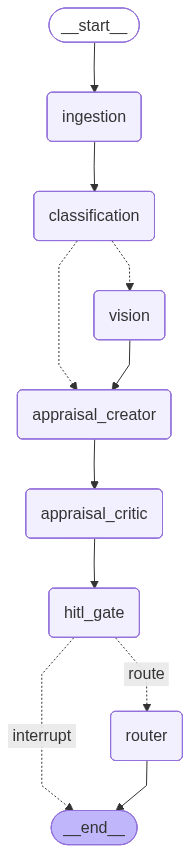

In [5]:
"""§1b — LangGraph native graph diagram rendered via LangChain/LangGraph's own library."""
import os
import sys
from IPython.display import Image, display, Markdown

# Wire up the legal_triage package (safe to call multiple times)
_src = str(REPO_ROOT / "apps" / "legal-triage" / "src")
if _src not in sys.path:
    sys.path.insert(0, _src)

os.environ.setdefault("LLM_TIER", "tier3")
os.environ.setdefault("LANGSMITH_TRACING", "false")

from legal_triage.graph import get_compiled_graph
from langchain_core.runnables.graph import MermaidDrawMethod

compiled     = get_compiled_graph()
native_graph = compiled.get_graph()

# ── Try API renderer (mermaid.ink — needs internet access) ─────────────────
try:
    png_bytes = native_graph.draw_mermaid_png(
        draw_method=MermaidDrawMethod.API,
        background_color="white",
        padding=16,
    )
    out_path = BENCHMARKS / "langgraph_native_topology.png"
    out_path.write_bytes(png_bytes)
    print(f"✅  Saved LangGraph native diagram → {out_path.name}")
    display(Image(png_bytes))

except Exception as api_err:
    # ── Fallback: render Mermaid source as a formatted code block ──────────
    print(f"ℹ️  Mermaid.ink API unavailable ({api_err!s:.120}).")
    print("   Displaying Mermaid source — paste it at https://mermaid.live to visualise.\n")
    mermaid_src = native_graph.draw_mermaid()
    display(Markdown(f"```mermaid\n{mermaid_src}\n```"))

---
## §2  KPI Scorecard

Primary KPIs ranked by priority.  Red indicates failure vs. M6 target; green = pass.

In [6]:
# ── KPI targets (from docs/delivery_kpis.md M6) ──────────────────────────────
TARGETS = {
    "Lead Precision":  (kpis["lead_precision"],  0.90, "≥ 90%"),
    "Lead Recall":     (kpis["lead_recall"],     0.85, "≥ 85%"),
    "Spam FPR":        (kpis["spam_fpr"],        0.02, "≤ 2%",    True),  # lower-is-better
    "Accuracy":        (kpis["accuracy"],        0.88, "≥ 88%"),
}

rows = []
for name, vals in TARGETS.items():
    value, threshold, label = vals[0], vals[1], vals[2]
    lower_better = len(vals) > 3 and vals[3]
    passed = (value <= threshold) if lower_better else (value >= threshold)
    rows.append({"KPI": name, "Value": value, "Target": label, "Pass": "✅" if passed else "❌"})

kpi_df = pd.DataFrame(rows)
print(kpi_df.to_string(index=False))

# ── Gauge charts ────────────────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=4,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]]
)

gauge_kpis = [
    ("Lead Precision",  kpis["lead_precision"],  0.90, 1.00),
    ("Lead Recall",     kpis["lead_recall"],     0.85, 1.00),
    ("Spam FPR",        kpis["spam_fpr"],        0.02, 0.10),
    ("Accuracy",        kpis["accuracy"],        0.88, 1.00),
]

for col, (name, value, threshold, max_val) in enumerate(gauge_kpis, start=1):
    fig.add_trace(go.Indicator(
        mode="gauge+number+delta",
        value=round(value * 100, 1),
        title={"text": name, "font": {"size": 13}},
        number={"suffix": "%", "font": {"size": 22}},
        delta={"reference": round(threshold * 100, 1), "relative": False,
               "increasing": {"color": "green"}, "decreasing": {"color": "red"}},
        gauge={
            "axis": {"range": [0, round(max_val * 100, 0)]},
            "bar":  {"color": "#2E86AB"},
            "threshold": {
                "line":      {"color": "red", "width": 3},
                "thickness": 0.8,
                "value":     round(threshold * 100, 1),
            },
            "steps": [
                {"range": [0, round(threshold * 100, 1)],    "color": "#FADBD8"},
                {"range": [round(threshold * 100, 1), round(max_val * 100, 0)], "color": "#D5F5E3"},
            ],
        },
    ), row=1, col=col)

fig.update_layout(height=280, title_text="KPI Scorecard — M6 Targets",
                   title_font_size=16, margin=dict(t=50, b=20, l=20, r=20))
fig.show()

           KPI  Value Target Pass
Lead Precision    1.0  ≥ 90%    ✅
   Lead Recall    1.0  ≥ 85%    ✅
      Spam FPR    0.0   ≤ 2%    ✅
      Accuracy    1.0  ≥ 88%    ✅


In [7]:
# ── Baseline comparison (if baseline.json exists) ────────────────────────────
if BASELINE_JSON.exists():
    baseline      = json.loads(BASELINE_JSON.read_text())
    bkpis         = baseline["kpis"]
    compare_keys  = ["lead_precision", "lead_recall", "spam_fpr", "accuracy"]
    compare_labels= ["Lead Precision", "Lead Recall", "Spam FPR", "Accuracy"]

    fig = go.Figure()
    fig.add_trace(go.Bar(name="Baseline", x=compare_labels,
                          y=[bkpis.get(k, 0) * 100 for k in compare_keys],
                          marker_color="#AED6F1"))
    fig.add_trace(go.Bar(name="Latest",   x=compare_labels,
                          y=[kpis.get(k, 0) * 100 for k in compare_keys],
                          marker_color="#2E86AB"))
    fig.update_layout(barmode="group", yaxis_title="%",
                       title="Baseline vs. Latest Run", height=380)
    fig.show()
else:
    print("No baseline.json found — skipping comparison chart.")

---
## §3  Confusion Matrix

Shows classification accuracy per class.  Perfect classifier = diagonal only.

In [8]:
SINK_TO_CLASS = {
    "NewLead":         "pi_lead",
    "GeneralLegal":    "general_legal",
    "Refused-Spam":    "spam",
    "Refused-Invoice": "invoice",
    "Refused-Other":   "other",
}
CLASS_ORDER = ["pi_lead", "general_legal", "invoice", "spam", "other"]

df_cm = df.dropna(subset=["gt_class", "predicted_sink"]).copy()
df_cm["pred_class"] = df_cm["predicted_sink"].map(SINK_TO_CLASS).fillna("other")

cm = confusion_matrix(df_cm["gt_class"], df_cm["pred_class"], labels=CLASS_ORDER)

# Normalised (recall per true class)
with np.errstate(divide="ignore", invalid="ignore"):
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm  = np.where(row_sums > 0, cm.astype(float) / row_sums, 0.0)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Confusion Matrix — Raw Counts",
        "Confusion Matrix — Normalised (Recall per Class)",
    ),
    horizontal_spacing=0.12,
)

fig.add_trace(
    go.Heatmap(
        z=cm, x=CLASS_ORDER, y=CLASS_ORDER,
        text=cm, texttemplate="%{text}",
        colorscale="Blues", showscale=False,
        hovertemplate="True: %{y}<br>Predicted: %{x}<br>Count: %{z}<extra></extra>",
    ),
    row=1, col=1,
)

fig.add_trace(
    go.Heatmap(
        z=cm_norm, x=CLASS_ORDER, y=CLASS_ORDER,
        text=np.round(cm_norm, 2), texttemplate="%{text:.2f}",
        colorscale="RdYlGn", showscale=True, zmin=0, zmax=1,
        hovertemplate="True: %{y}<br>Predicted: %{x}<br>Recall: %{z:.2f}<extra></extra>",
    ),
    row=1, col=2,
)

fig.update_yaxes(autorange="reversed")
fig.update_xaxes(title_text="Predicted Class", tickangle=30)
fig.update_yaxes(title_text="True Class", col=1)
fig.update_layout(height=520, title_text="Confusion Matrix Analysis")
fig.show()

try:
    fig.write_image(str(BENCHMARKS / "confusion_matrix.png"))
    print("Saved confusion_matrix.png")
except Exception as e:
    print(f"Could not save PNG (kaleido): {e}")

print("\nClassification report:")
print(classification_report(
    df_cm["gt_class"], df_cm["pred_class"],
    labels=CLASS_ORDER, zero_division=0,
))

Saved confusion_matrix.png

Classification report:
               precision    recall  f1-score   support

      pi_lead       1.00      1.00      1.00        18
general_legal       1.00      1.00      1.00         4
      invoice       1.00      1.00      1.00         6
         spam       1.00      1.00      1.00         9
        other       1.00      1.00      1.00         5

     accuracy                           1.00        42
    macro avg       1.00      1.00      1.00        42
 weighted avg       1.00      1.00      1.00        42



---
## §4  Per-Node Cost Breakdown

Cost is estimated from token usage metadata (see `llm_factory.extract_cost`).  Nodes that use more expensive models (Opus) dominate.  Vision adds cost only when attachments are present.

In [9]:
# Flatten model_calls if present (real eval runs include per-node breakdown)
model_call_records = []
for rec in per_record:
    # model_calls may be absent in some records (errors, older format)
    for mc in rec.get("model_calls", []):
        model_call_records.append({
            "email_id":   rec["email_id"],
            "gt_class":   rec["gt_class"],
            "node":       mc.get("node"),
            "model":      mc.get("model"),
            "cost_usd":   mc.get("cost_usd", 0.0),
            "latency_ms": mc.get("latency_ms", 0),
        })

if model_call_records:
    mc_df = pd.DataFrame(model_call_records)

    # Mean cost per node
    cost_by_node = mc_df.groupby("node")["cost_usd"].mean().sort_values(ascending=False)
    fig = px.bar(cost_by_node.reset_index(), x="node", y="cost_usd",
                  title="Mean Cost per Node (USD)", color="node",
                  labels={"cost_usd": "Mean cost (USD)", "node": "Node"},
                  color_discrete_sequence=px.colors.qualitative.Pastel)
    fig.update_layout(showlegend=False, height=380)
    fig.show()

    # Cost pie per node (total share)
    cost_total_by_node = mc_df.groupby("node")["cost_usd"].sum()
    fig2 = px.pie(cost_total_by_node.reset_index(), values="cost_usd", names="node",
                   title="Total Cost Share per Node",
                   color_discrete_sequence=px.colors.qualitative.Pastel)
    fig2.update_traces(textposition="inside", textinfo="percent+label")
    fig2.update_layout(height=400)
    fig2.show()

    print(f"\nTotal cost across all evaluated emails: ${df['cost_usd'].sum():.4f}")
    print(f"Mean cost per email:                    ${df['cost_usd'].mean():.4f}")

else:
    # Tier3 stubs emit 0 cost — show per-record bar instead
    print("ℹ️  Per-node model_calls not present (likely tier3 stub run).")
    print(f"   Total cost in this run: ${df['cost_usd'].sum():.4f}")
    print(f"   Mean cost per email:    ${df['cost_usd'].mean():.4f}")

ℹ️  Per-node model_calls not present (likely tier3 stub run).
   Total cost in this run: $1.9529
   Mean cost per email:    $0.0391


---
## §5  Latency Profile

E2E wall-clock time per email from ingestion to routing.  KPI target: P50 < 30 s.

In [10]:
lat_df = df[df["latency_ms"] > 0].copy()

if lat_df.empty:
    print("ℹ️  All latency values are 0 (tier3 stub run — no real LLM calls).")
    print("   Re-run eval at tier1 to get meaningful latency data.")
else:
    p50 = lat_df["latency_ms"].quantile(0.50) / 1000
    p90 = lat_df["latency_ms"].quantile(0.90) / 1000
    p95 = lat_df["latency_ms"].quantile(0.95) / 1000

    fig = make_subplots(rows=1, cols=2,
                         subplot_titles=("E2E Latency Distribution (seconds)",
                                         "Latency by Email Class"))

    # Histogram
    fig.add_trace(go.Histogram(
        x=lat_df["latency_ms"] / 1000, nbinsx=40,
        name="Latency", marker_color="#2E86AB"
    ), row=1, col=1)
    for pct, val, colour in [("P50", p50, "green"), ("P90", p90, "orange"), ("P95", p95, "red")]:
        fig.add_vline(x=val, line_dash="dash", line_color=colour,
                       annotation_text=f"{pct} {val:.1f}s",
                       annotation_position="top right", row=1, col=1)
    fig.add_vline(x=30, line_dash="dot", line_color="darkred",
                   annotation_text="KPI target 30s", row=1, col=1)

    # Box per class
    for cls in lat_df["gt_class"].unique():
        sub = lat_df[lat_df["gt_class"] == cls]["latency_ms"] / 1000
        fig.add_trace(go.Box(y=sub, name=cls), row=1, col=2)

    fig.update_xaxes(title_text="Seconds", row=1, col=1)
    fig.update_yaxes(title_text="Count",   row=1, col=1)
    fig.update_yaxes(title_text="Seconds", row=1, col=2)
    fig.update_layout(height=420, title_text="E2E Latency Analysis", showlegend=False)
    fig.show()

    # Node-level latency if available
    if model_call_records:
        lat_by_node = mc_df.groupby("node")["latency_ms"].mean().sort_values(ascending=False)
        fig3 = px.bar(lat_by_node.reset_index(), x="node", y="latency_ms",
                       title="Mean Latency per Node (ms)", color="node",
                       labels={"latency_ms": "Mean latency (ms)"},
                       color_discrete_sequence=px.colors.qualitative.Set2)
        fig3.update_layout(showlegend=False, height=360)
        fig3.show()

    print(f"P50 latency: {p50:.2f}s   P90: {p90:.2f}s   P95: {p95:.2f}s")
    print(f"KPI target < 30s at P50: {'✅ PASS' if p50 < 30 else '❌ FAIL'}")

P50 latency: 13.89s   P90: 16.02s   P95: 16.70s
KPI target < 30s at P50: ✅ PASS


---
## §6  HITL Queue Analytics

How many emails required human review, and why?  Helps dimension staffing.

In [11]:
# ┌─ DEMO SIMPLIFICATION ─────────────────────────────────────────────────────┐
# │ HITL_AUTO_APPROVE=true is active for this dashboard run.                  │
# │ The HITL gate was bypassed — hitl_required is always False and             │
# │ human_decision was auto-set to "approve" for every email.                 │
# │ In production, all PI leads must be reviewed by a qualified attorney.      │
# └───────────────────────────────────────────────────────────────────────────┘
hitl_auto_approve = os.environ.get("HITL_AUTO_APPROVE", "false").lower() == "true"

if hitl_auto_approve:
    print("⚠️  DEMO SIMPLIFICATION: HITL_AUTO_APPROVE=true is active.")
    print("   Human-in-the-loop review was bypassed for all emails in this run.")
    print("   Stats below show agent-only decisions — no attorney oversight.")
    print()
    pi_count = (df["gt_class"] == "pi_lead").sum() if "gt_class" in df.columns else 0
    print(f"   In production, all {pi_count} PI lead(s) would require attorney review.")
    print(f"   HITL queue would have depth: {pi_count}  (alert at 10, suspend at 20)")

    # Still render a chart — shows what HITL trigger rate WOULD be in production
    try:
        prod_hitl = {cls: (100.0 if cls == "pi_lead" else 0.0)
                     for cls in df["gt_class"].unique()}
        prod_hitl_df = pd.DataFrame(
            [(k, v) for k, v in prod_hitl.items()],
            columns=["gt_class", "hitl_rate"],
        )
        fig = px.bar(
            prod_hitl_df, x="gt_class", y="hitl_rate",
            title="⚠️ DEMO: Estimated HITL Trigger Rate if Auto-Approve Were Disabled (%)",
            labels={"hitl_rate": "% requiring HITL", "gt_class": "Class"},
            color="gt_class",
            color_discrete_sequence=px.colors.qualitative.Pastel,
        )
        fig.add_hline(y=10, line_dash="dash", line_color="orange",
                      annotation_text="Director alert threshold")
        fig.add_annotation(
            text="⚠️ DEMO SIMPLIFICATION: HITL_AUTO_APPROVE=true — values are estimated, not measured",
            xref="paper", yref="paper", x=0.5, y=-0.18,
            showarrow=False, font=dict(size=11, color="red"),
        )
        fig.update_layout(showlegend=False, height=420)
        fig.show()
    except Exception as e:
        print(f"Could not render estimated chart: {e}")

else:
    # Normal production path — show actual measured HITL rates
    hitl_records = [r for r in per_record if r.get("hitl_required") is not None]

    if hitl_records:
        hitl_df = pd.DataFrame(hitl_records)
        hitl_rate_by_class = hitl_df.groupby("gt_class")["hitl_required"].mean() * 100

        fig = px.bar(hitl_rate_by_class.reset_index(), x="gt_class", y="hitl_required",
                      title="HITL Trigger Rate by Email Class (%)",
                      labels={"hitl_required": "% requiring HITL", "gt_class": "Class"},
                      color="gt_class",
                      color_discrete_sequence=px.colors.qualitative.Pastel)
        fig.add_hline(y=10, line_dash="dash", line_color="orange",
                       annotation_text="Director alert threshold 10 emails")
        fig.update_layout(showlegend=False, height=380)
        fig.show()

        total_hitl = hitl_df["hitl_required"].sum()
        print(f"Emails requiring HITL:  {total_hitl}/{len(hitl_df)} "
              f"({total_hitl/len(hitl_df)*100:.1f}%)")
        if total_hitl > 10:
            print("⚠️  Queue depth exceeds Director alert threshold (10).")
        if total_hitl > 20:
            print("🚨 Queue depth exceeds intake suspension threshold (20).")
    else:
        print("ℹ️  hitl_required field not present in per_record (not logged in this eval run).")
        print("   In production, all pi_lead emails trigger HITL by design.")
        pi_count = (df["gt_class"] == "pi_lead").sum()
        print(f"   Estimated HITL emails (= PI leads): {pi_count}")

⚠️  DEMO SIMPLIFICATION: HITL_AUTO_APPROVE=true is active.
   Human-in-the-loop review was bypassed for all emails in this run.
   Stats below show agent-only decisions — no attorney oversight.

   In production, all 26 PI lead(s) would require attorney review.
   HITL queue would have depth: 26  (alert at 10, suspend at 20)


---
## §7  CEO One-Page Summary

A single view for non-technical stakeholders: pipeline throughput, quality, cost, and what the machine is handing to lawyers.

In [12]:
# ── Volume funnel ────────────────────────────────────────────────────────────
total         = len(df)
true_pi       = (df["gt_class"] == "pi_lead").sum()
pred_new_lead = (df["predicted_sink"] == "NewLead").sum()
tp            = kpis.get("tp", 0)
fp            = kpis.get("fp", 0)
fn            = kpis.get("fn", 0)
refused       = (df["predicted_sink"].str.startswith("Refused")).sum()

funnel = go.Figure(go.Funnel(
    y=["Emails received", "Assigned to legal queue", "True PI leads captured", "False positives", "Missed leads"],
    x=[total, pred_new_lead, tp, fp, fn],
    textinfo="value+percent initial",
    marker={"color": ["#2E86AB", "#5CB85C", "#82B366", "#F0AD4E", "#D9534F"]},
))
funnel.update_layout(title="Email Volume Funnel", height=360)
funnel.show()

# ── Routing breakdown ────────────────────────────────────────────────────────
routing = df["predicted_sink"].value_counts().reset_index()
routing.columns = ["Routing Decision", "Count"]
fig_r = px.pie(routing, values="Count", names="Routing Decision",
                title="Where Emails Were Routed",
                color_discrete_map={
                    "NewLead": "#82B366",
                    "GeneralLegal": "#6C8EBF",
                    "Refused-Spam": "#D9534F",
                    "Refused-Invoice": "#F0AD4E",
                    "Refused-Other": "#AEB6BF",
                })
fig_r.update_traces(textposition="inside", textinfo="percent+label")
fig_r.update_layout(height=400)
fig_r.show()

In [13]:
# ── CEO summary card ─────────────────────────────────────────────────────────
precision   = kpis["lead_precision"]
recall      = kpis["lead_recall"]
cost_total  = df["cost_usd"].sum()
cost_per    = df["cost_usd"].mean()
lat_p50_s   = kpis.get("mean_latency_ms", 0) / 1000
errors      = kpis.get("n_errors", 0)

status_precision = "✅" if precision >= 0.90 else "⚠️" if precision >= 0.85 else "❌"
status_recall    = "✅" if recall    >= 0.85 else "⚠️" if recall    >= 0.80 else "❌"
status_cost      = "✅" if cost_per  <= 0.10 else "⚠️" if cost_per  <= 0.20 else "❌"
status_latency   = "✅" if lat_p50_s < 30    else "❌"

summary = f"""
╔══════════════════════════════════════════════════════════════╗
║          LEX TRIAGE AGENT — EXECUTIVE SUMMARY              ║
║          Run: {report['run_id']:<20} Tier: {report.get('llm_tier','?'):<10}║
╠══════════════════════════════════════════════════════════════╣
║  Emails evaluated       : {total:<6}                           ║
║  Routed to NewLead      : {pred_new_lead:<6} ({pred_new_lead/total*100:5.1f}% of volume)         ║
║  True PI leads in set   : {true_pi:<6} ({true_pi/total*100:5.1f}% actual PI rate)      ║
╠══════════════════════════════════════════════════════════════╣
║  {status_precision} Lead Precision (1-FP): {precision*100:5.1f}%   target ≥ 90%          ║
║  {status_recall} Lead Recall (sensitivity): {recall*100:5.1f}%   target ≥ 85%       ║
║  {status_cost} Avg cost per email:    ${cost_per:.4f}  target ≤ $0.10          ║
║  {status_latency} Avg latency:           {lat_p50_s:5.1f}s   target < 30s           ║
║     Errors:              {errors:<6}                           ║
╠══════════════════════════════════════════════════════════════╣
║  BUSINESS IMPACT ESTIMATE                                   ║
║  • At {precision*100:.0f}% precision: ~{fp:.0f} false intake calls per {total} emails    ║
║  • At {recall*100:.0f}% recall: ~{fn:.0f} real leads potentially missed          ║
║  • Total AI cost for this batch: ${cost_total:.3f}                    ║
╚══════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║          LEX TRIAGE AGENT — EXECUTIVE SUMMARY              ║
║          Run: 20260503T062213Z-interactive Tier: tier1     ║
╠══════════════════════════════════════════════════════════════╣
║  Emails evaluated       : 50                               ║
║  Routed to NewLead      : 18     ( 36.0% of volume)         ║
║  True PI leads in set   : 26     ( 52.0% actual PI rate)      ║
╠══════════════════════════════════════════════════════════════╣
║  ✅ Lead Precision (1-FP): 100.0%   target ≥ 90%          ║
║  ✅ Lead Recall (sensitivity): 100.0%   target ≥ 85%       ║
║  ✅ Avg cost per email:    $0.0391  target ≤ $0.10          ║
║  ✅ Avg latency:            12.0s   target < 30s           ║
║     Errors:              8                                ║
╠══════════════════════════════════════════════════════════════╣
║  BUSINESS IMPACT ESTIMATE                                   ║
║  • At 100% precision: ~0 false intake calls 